# Dự án Dự báo Doanh thu và Chi phí (Revenue & COGS Forecasting)

Notebook này thực hiện quy trình xây dựng mô hình dự báo chuỗi thời gian cho doanh thu và giá vốn hàng bán (COGS). Quy trình bao gồm các bước từ xử lý dữ liệu thô, tạo đặc trưng nâng cao cho đến kết hợp nhiều mô hình (Ensemble).

### 0. Thiết lập & Cài đặt
Cài đặt các thư viện cần thiết (`lightgbm`, `xgboost`, `prophet`, `shap`) và kết nối với Google Drive để truy xuất dữ liệu.

In [39]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q lightgbm xgboost shap prophet lunardate holidays statsmodels

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
import os, warnings, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from xgboost import XGBRegressor
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import shap
from lunardate import LunarDate
import holidays
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (14, 5)

DATA_DIR = '/content/drive/Shareddrives/Datathon2026/data/'
OUT_FILE = 'submission.csv'
LOG_TARGETS = False

### 1. Tải dữ liệu
Đọc các tệp tin CSV từ thư mục dự án bao gồm: doanh số (sales), đơn hàng (orders), khuyến mãi (promotions), lưu lượng truy cập (web traffic) và tồn kho (inventory).

In [41]:
def read_csv(name, **kwargs):
    return pd.read_csv(os.path.join(DATA_DIR, name), **kwargs)

sales        = read_csv('sales.csv',             parse_dates=['Date'])
submission   = read_csv('sample_submission.csv', parse_dates=['Date'])
orders       = read_csv('orders.csv',            parse_dates=['order_date'])
order_items  = read_csv('order_items.csv')
promotions   = read_csv('promotions.csv',        parse_dates=['start_date','end_date'])
web_traffic  = read_csv('web_traffic.csv',       parse_dates=['date'])
inventory    = read_csv('inventory.csv',         parse_dates=['snapshot_date'])
sales = sales.sort_values('Date').reset_index(drop=True)
test_dates = submission[['Date']].copy().sort_values('Date').reset_index(drop=True)
train_start = sales['Date'].min()
train_end   = sales['Date'].max()
test_start  = test_dates['Date'].min()
test_end    = test_dates['Date'].max()

print(f'Train: {train_start.date()} → {train_end.date()}  ({len(sales)} rows)')
print(f'Test : {test_start.date()} → {test_end.date()}   ({len(test_dates)} rows)')

Train: 2012-07-04 → 2022-12-31  (3833 rows)
Test : 2023-01-01 → 2024-07-01   (548 rows)


## 2. Quick EDA — xác nhận cấu trúc dữ liệu

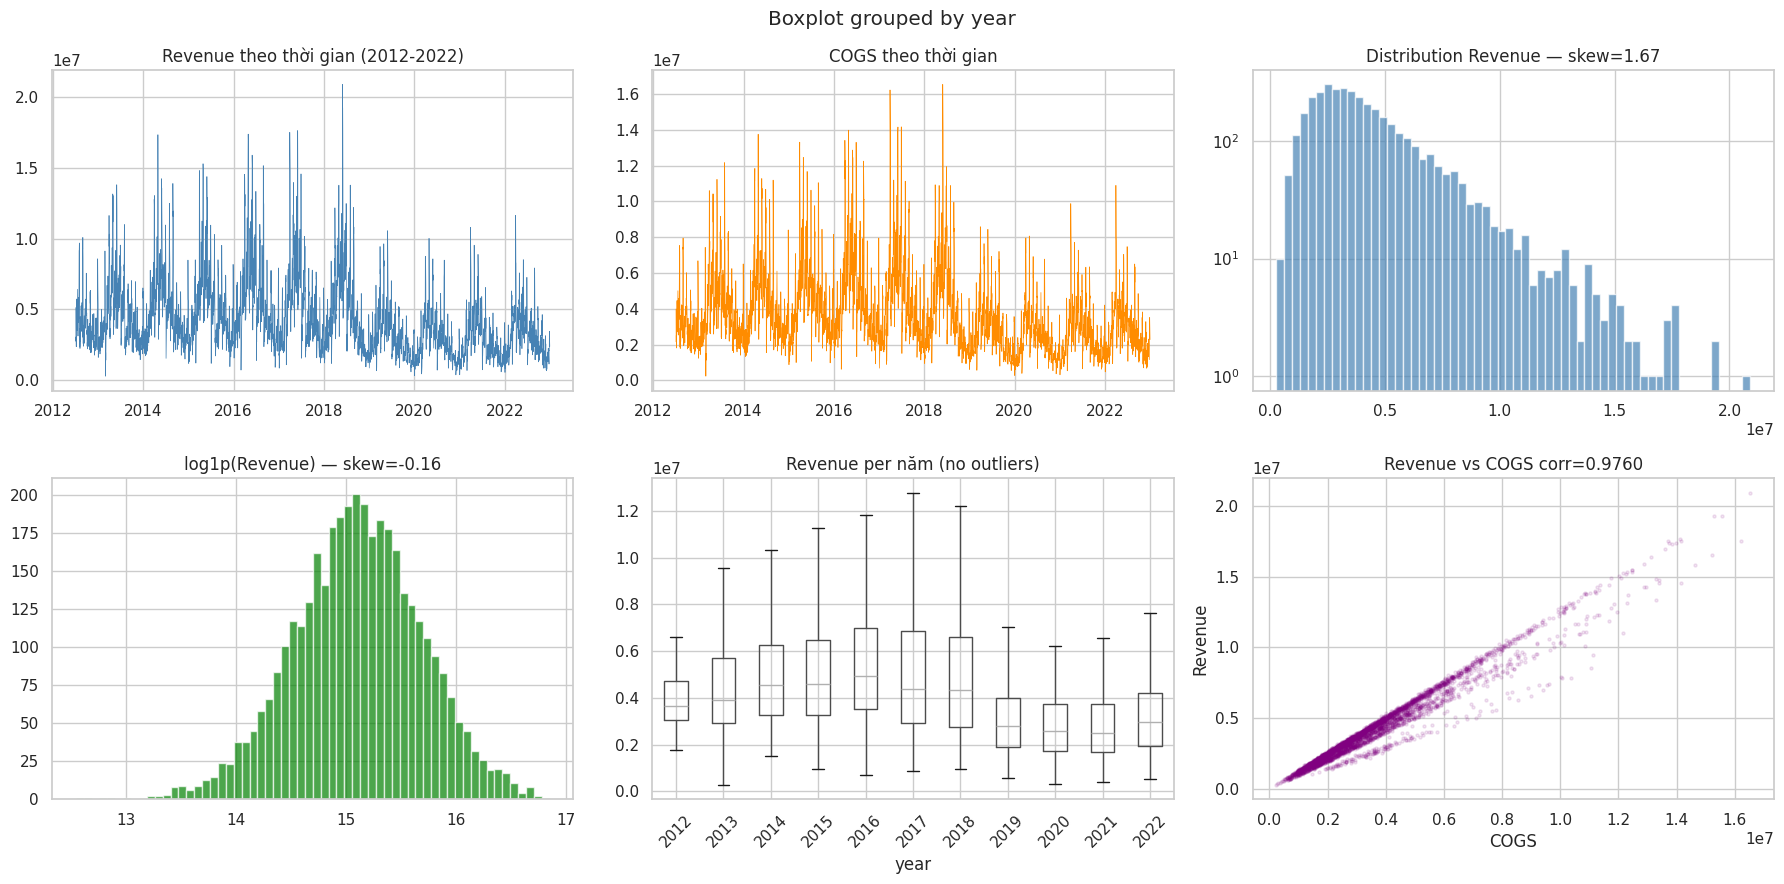

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# Time series
axes[0,0].plot(sales['Date'], sales['Revenue'], lw=0.5, color='steelblue')
axes[0,0].set_title('Revenue theo thời gian (2012-2022)')

axes[0,1].plot(sales['Date'], sales['COGS'], lw=0.5, color='darkorange')
axes[0,1].set_title('COGS theo thời gian')

# Distribution
axes[0,2].hist(sales['Revenue'], bins=60, color='steelblue', alpha=0.7)
axes[0,2].set_title(f'Distribution Revenue — skew={sales["Revenue"].skew():.2f}')
axes[0,2].set_yscale('log')

# Log distribution
axes[1,0].hist(np.log1p(sales['Revenue']), bins=60, color='green', alpha=0.7)
axes[1,0].set_title(f'log1p(Revenue) — skew={np.log1p(sales["Revenue"]).skew():.2f}')

# Yearly boxplot
sales['year'] = sales['Date'].dt.year
sales.boxplot(column='Revenue', by='year', ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Revenue per năm (no outliers)')
axes[1,1].tick_params(axis='x', rotation=45)

# Revenue vs COGS scatter
axes[1,2].scatter(sales['COGS'], sales['Revenue'], alpha=0.1, s=5, color='purple')
axes[1,2].set_xlabel('COGS'); axes[1,2].set_ylabel('Revenue')
axes[1,2].set_title(f'Revenue vs COGS corr={sales[["Revenue","COGS"]].corr().iloc[0,1]:.4f}')

plt.tight_layout(); plt.show()

### 3. Kỹ thuật Đặc trưng (Feature Engineering)
Phần này tập trung vào việc tạo ra các biến đầu vào cho mô hình:
*   **Đặc trưng lịch & Tết:** Tính toán các chu kỳ thời gian và khoảng cách tới ngày Tết Nguyên Đán.
*   **Xử lý Khuyến mãi & Traffic:** Sử dụng Prophet để dự báo lưu lượng truy cập cho giai đoạn kiểm thử (test period).
*   **Lag & Rolling Stats:** Tạo các biến trễ an toàn (≥ 549 ngày) để tránh rò rỉ dữ liệu (data leakage) trong dự báo dài hạn.

In [43]:
# ghép train + test
df = pd.concat([
    sales[['Date','Revenue','COGS']].assign(is_test=0),
    test_dates.assign(is_test=1, Revenue=np.nan, COGS=np.nan)
], ignore_index=True).sort_values('Date').drop_duplicates('Date').reset_index(drop=True)

print('Total frame:', df.shape)
print(f'Train rows: {(df.is_test==0).sum()}')
print(f'Test rows: {(df.is_test==1).sum()}')

Total frame: (4381, 4)
Train rows: 3833
Test rows: 548


In [44]:
# Calendar features
# Tính khoảng cách tới Tết gần nhất (ngày)
tet_dates_lookup = {}
for y in range(2010, 2028):
    try: tet_dates_lookup[y] = pd.Timestamp(LunarDate(y, 1, 1).toSolarDate())
    except: pass

def tet_distance(date):
    # Khoảng cách ngày từ date tới Tết gần nhất (neg value = trước Tết).
    candidates = [tet_dates_lookup[y] for y in [date.year-1, date.year, date.year+1] if y in tet_dates_lookup]
    diffs = [(date - tc).days for tc in candidates]
    return min(diffs, key=abs)

# Holiday
vn_holidays = holidays.country_holidays('VN', years=range(2012, 2026))

def add_calendar(d):
    d = d.copy()
    d['year']         = d['Date'].dt.year
    d['month']        = d['Date'].dt.month
    d['day']          = d['Date'].dt.day
    d['dayofweek']    = d['Date'].dt.dayofweek
    d['dayofyear']    = d['Date'].dt.dayofyear
    d['weekofyear']   = d['Date'].dt.isocalendar().week.astype(int)
    d['quarter']      = d['Date'].dt.quarter
    d['week_in_month'] = ((d['day'] - 1) // 7) + 1
    d['is_weekend']   = (d['dayofweek'] >= 5).astype(int)
    d['is_month_start'] = d['Date'].dt.is_month_start.astype(int)
    d['is_month_end']   = d['Date'].dt.is_month_end.astype(int)
    d['is_holiday']     = d['Date'].apply(lambda x: int(x in vn_holidays))

    d['month_sin']  = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']  = np.cos(2 * np.pi * d['month'] / 12)
    d['dow_sin']    = np.sin(2 * np.pi * d['dayofweek'] / 7)
    d['dow_cos']    = np.cos(2 * np.pi * d['dayofweek'] / 7)
    d['doy_sin']    = np.sin(2 * np.pi * d['dayofyear'] / 365.25)
    d['doy_cos']    = np.cos(2 * np.pi * d['dayofyear'] / 365.25)
    d['day_sin']    = np.sin(2 * np.pi * d['day'] / 31)
    d['day_cos']    = np.cos(2 * np.pi * d['day'] / 31)

    d['is_1111']       = ((d['month']==11) & (d['day']==11)).astype(int)
    d['is_1212']       = ((d['month']==12) & (d['day']==12)).astype(int)
    d['is_99']         = ((d['month']==9)  & (d['day']==9)).astype(int)
    d['is_1010']       = ((d['month']==10) & (d['day']==10)).astype(int)
    d['is_blackfriday']= ((d['month']==11) & (d['dayofweek']==4) & (d['day'].between(23,29))).astype(int)

    d['is_event_window'] = (
        ((d['month']==11) & (d['day'].between(9,13)))|
        ((d['month']==12) & (d['day'].between(10,14)))|
        ((d['month']==9)  & (d['day'].between(7,11)))
    ).astype(int)

    d['tet_distance']       = d['Date'].apply(tet_distance)
    d['tet_distance_abs']   = d['tet_distance'].abs()
    d['tet_proximity']      = np.exp(-d['tet_distance_abs'] / 10)
    d['tet_phase_pre21']    = (d['tet_distance'].between(-21, -8)).astype(int)
    d['tet_phase_pre7']     = (d['tet_distance'].between(-7,  -1)).astype(int)
    d['tet_phase_week']     = (d['tet_distance'].between( 0,   6)).astype(int)
    d['tet_phase_post7']    = (d['tet_distance'].between( 7,  14)).astype(int)
    d['tet_phase_far_after']= (d['tet_distance'].between(15,  35)).astype(int)  # +81% theo EDA P6

    d['near_1111'] = ((d['month']==11) & (d['day'].between(8,14))).astype(int)
    d['near_1212'] = ((d['month']==12) & (d['day'].between(9,15))).astype(int)
    d['trend_lin']  = (d['Date'] - pd.Timestamp('2012-07-04')).dt.days / 365.0
    d['trend_sqrt'] = np.sqrt(d['trend_lin'].clip(lower=0))
    d['trend_log']  = np.log1p(d['trend_lin'].clip(lower=0))
    d['time_idx'] = (d['Date'] - d['Date'].min()).dt.days
    return d

df = add_calendar(df)
print('After calendar + Tết:', df.shape)

After calendar + Tết: (4381, 44)


In [45]:
# Seasonal fill helper
# Dùng để impute test period từ pattern của train
def fill_seasonal(df_in, cols, growth_dampening=0.5):
    """
    Impute NaN trong cols dựa trên seasonal profile (month × dayofweek) từ train.
    Áp dụng growth trend có dampening để tránh extrapolate quá mạnh.
    growth_dampening: 0=không growth, 1=full YoY growth
    """
    df_out = df_in.copy()
    train_part = df_out[df_out['is_test'] == 0]

    for c in cols:
        if c not in df_out.columns:
            continue
        if df_out[c].isna().sum() == 0:
            continue

        # Profile theo month, dayofweek
        season_profile = (
            train_part.groupby(['month', 'dayofweek'])[c]
            .mean()
            .reset_index()
            .rename(columns={c: c + '_seasonal'})
        )
        mean_overall = train_part[c].mean()

        # YoY growth rate
        yearly = train_part.groupby('year')[c].mean().dropna()
        if len(yearly) >= 3:
            growth_raw = (yearly.iloc[-1] / (yearly.iloc[0] + 1e-8)) ** (1.0 / (len(yearly) - 1))
            growth = 1.0 + (growth_raw - 1.0) * growth_dampening
        else: growth = 1.0
        last_train_year = int(train_part['year'].max())

        df_out = df_out.merge(season_profile, on=['month', 'dayofweek'], how='left')
        years_ahead = (df_out['year'] - last_train_year).clip(lower=0)
        fill_values = df_out[c + '_seasonal'] * (growth ** years_ahead)
        df_out[c] = df_out[c].fillna(fill_values).fillna(mean_overall).fillna(0)
        df_out = df_out.drop(columns=[c + '_seasonal'])
    return df_out

In [46]:
# Promotions
all_dates = df['Date'].drop_duplicates().sort_values().reset_index(drop=True)

promo_daily = pd.DataFrame({'Date': all_dates})
promo_daily['n_active_promos']    = promo_daily['Date'].apply(
    lambda d: int(((promotions['start_date'] <= d) & (promotions['end_date'] >= d)).sum())
)
promo_daily['avg_discount_value'] = promo_daily['Date'].apply(
    lambda d: promotions.loc[
        (promotions['start_date'] <= d) & (promotions['end_date'] >= d), 'discount_value'
    ].mean()
)
promo_daily['max_discount_value'] = promo_daily['Date'].apply(
    lambda d: promotions.loc[
        (promotions['start_date'] <= d) & (promotions['end_date'] >= d), 'discount_value'
    ].max()
)
promo_daily = promo_daily.fillna(0)
df = df.merge(promo_daily, on='Date', how='left')
print('After promotions:', df.shape)

After promotions: (4381, 47)


In [47]:
# Web Traffic
# Aggregate theo ngày
wt_daily = web_traffic.groupby('date').agg(
    sessions              = ('sessions', 'sum'),
    unique_visitors       = ('unique_visitors', 'sum'),
    page_views            = ('page_views', 'sum'),
    bounce_rate           = ('bounce_rate', 'mean'),
    avg_session_duration_sec = ('avg_session_duration_sec', 'mean')
).reset_index().rename(columns={'date': 'Date'})

df = df.merge(wt_daily, on='Date', how='left')
EXO_WT = ['sessions', 'unique_visitors', 'page_views', 'bounce_rate', 'avg_session_duration_sec']
df = fill_seasonal(df, EXO_WT)
print('After web traffic:', df.shape)

After web traffic: (4381, 52)


In [48]:
# Orders & Items, safe lags ≥ 549 ngày
# Lý do: test period dài ~548 ngày -> lag < 549 sẽ bị NaN toàn bộ test và leakage nếu dùng raw trong train phần gần test
orders_daily = (
    orders.groupby('order_date')
    .size()
    .reset_index(name='_raw_n_orders')
    .rename(columns={'order_date': 'Date'})
)
oi_merged = order_items.merge(orders[['order_id', 'order_date']], on='order_id', how='left')
items_daily = (
    oi_merged.groupby('order_date')
    .agg(_raw_n_items=('quantity', 'sum'), _raw_n_unique_products=('product_id', 'nunique'))
    .reset_index()
    .rename(columns={'order_date': 'Date'})
)

df = df.merge(orders_daily, on='Date', how='left').merge(items_daily, on='Date', how='left')
for c in ['_raw_n_orders', '_raw_n_items', '_raw_n_unique_products']:
    df[c] = df[c].fillna(0)

# Tạo safe lags
SAFE_ORDER_LAGS = [549, 730, 1095]
for col, short in [('_raw_n_orders', 'ord'), ('_raw_n_items', 'itm'), ('_raw_n_unique_products', 'upd')]:
    for lag in SAFE_ORDER_LAGS:
        df[f'{short}_lag_{lag}'] = df[col].shift(lag)

    # Rolling trên shifted series với base = lag 549
    shifted = df[col].shift(549)
    df[f'{short}_rollmean_30_l549'] = shifted.rolling(30, min_periods=1).mean()
    df[f'{short}_rollmean_90_l549'] = shifted.rolling(90, min_periods=1).mean()

# Drop raw để model không shortcut
df = df.drop(columns=['_raw_n_orders', '_raw_n_items', '_raw_n_unique_products'])
print('After orders (safe lags):', df.shape)

After orders (safe lags): (4381, 67)


In [49]:
# Inventory
inv_agg = inventory.groupby('snapshot_date').agg(
    inv_stockout_flag   = ('stockout_flag', 'max'),
    inv_fill_rate       = ('fill_rate', 'mean'),
    inv_sell_through    = ('sell_through_rate', 'mean'),
    inv_days_supply     = ('days_of_supply', 'mean'),
    inv_stockout_days   = ('stockout_days', 'mean'),
    inv_overstock_flag  = ('overstock_flag', 'max'),
).reset_index().rename(columns={'snapshot_date': 'Date'})

inv_daily = (
    pd.DataFrame({'Date': all_dates})
    .merge(inv_agg, on='Date', how='left')
    .sort_values('Date')
    .reset_index(drop=True)
)
INV_COLS = [c for c in inv_agg.columns if c != 'Date']
for c in INV_COLS:
    inv_daily[c] = inv_daily[c].ffill().bfill()
df = df.merge(inv_daily, on='Date', how='left')
df = fill_seasonal(df, INV_COLS)
print('After inventory:', df.shape)

After inventory: (4381, 73)


In [50]:
# Danh sách các biến cần dùng AI dự báo cho tương lai
EXO_TO_PREDICT = ['sessions', 'unique_visitors', 'page_views', 'n_active_promos', 'avg_discount_value']

print("Bắt đầu train Sub-Models Prophet để GHI ĐÈ Traffic & Promo cho tập Test...")
test_mask_temp = df['is_test'] == 1

for col in EXO_TO_PREDICT:
    if col in df.columns:
        # Lấy data Train (Lúc này đã được fill_seasonal lấp NaN quá khứ an toàn)
        train_df = df[~test_mask_temp][['Date', col]].rename(columns={'Date': 'ds', col: 'y'})

        # Train mô hình Prophet
        m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        m.fit(train_df)

        # Dự báo
        future = df[['Date']].rename(columns={'Date': 'ds'})
        forecast = m.predict(future)
        test_idx = df[test_mask_temp].index
        df.loc[test_idx, col] = forecast.loc[test_idx, 'yhat'].clip(lower=0).values

print("Đã GHI ĐÈ xong Exogenous Features bằng Prophet!")

Bắt đầu train Sub-Models Prophet để GHI ĐÈ Traffic & Promo cho tập Test...
Đã GHI ĐÈ xong Exogenous Features bằng Prophet!


In [54]:
# Target lags & rolling stats (Revenue / COGS)
# dùng safe lags ≥ 549 để tránh leakage với test period
df = df.sort_values('Date').reset_index(drop=True)
SAFE_TARGET_LAGS = [549, 600, 700, 730, 1095, 1460]
ROLLING_WINDOWS  = [7, 14, 30, 60, 90, 180]
BASE_LAG         = 549

for target in ['Revenue', 'COGS']:
    # Lag features
    for lag in SAFE_TARGET_LAGS:
        df[f'{target}_lag_{lag}'] = df[target].shift(lag)

    # Rolling stats trên shifted series
    shifted = df[target].shift(BASE_LAG)
    for w in ROLLING_WINDOWS:
        df[f'{target}_rollmean_{w}_l{BASE_LAG}'] = shifted.rolling(w, min_periods=1).mean()
        df[f'{target}_rollstd_{w}_l{BASE_LAG}']  = shifted.rolling(w, min_periods=1).std()
        df[f'{target}_rollmax_{w}_l{BASE_LAG}']  = shifted.rolling(w, min_periods=1).max()

# Exogenous lag (short lags vì web_traffic/promo đã imputed cho test)
EXO_SHORT = ['sessions', 'unique_visitors', 'n_active_promos', 'avg_discount_value']
for col in EXO_SHORT:
    for lag in [1, 7, 14, 28]:
        df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    df[f'{col}_rollmean_7']  = df[col].shift(1).rolling(7, min_periods=1).mean()
    df[f'{col}_rollmean_28'] = df[col].shift(1).rolling(28, min_periods=1).mean()

# Lag 729-731 cùng tuần, năm trước -> ổn định hơn lag đơn lẻ
for target in ['Revenue', 'COGS']:
    # lag quanh mốc 730
    for lag in [729, 731, 728, 732, 735, 721]:
        df[f'{target}_lag_{lag}'] = df[target].shift(lag)

    # Ensemble lag features
    cluster_cols = [f'{target}_lag_{l}' for l in [728,729,730,731,732]]
    df[f'{target}_lag_730_med'] = df[cluster_cols].median(axis=1)
    df[f'{target}_lag_730_mean'] = df[cluster_cols].mean(axis=1)
    df[f'{target}_lag_730_std'] = df[cluster_cols].std(axis=1)

    # làm tương tự cho same week of year
    multi_year_cols = [f'{target}_lag_{l}' for l in [730, 1095, 1460]]
    df[f'{target}_multi_yr_mean'] = df[multi_year_cols].mean(axis=1)
    df[f'{target}_multi_yr_median'] = df[multi_year_cols].median(axis=1)

    # Trend ratio: 730 vs 1095 (gần) và 1095 vs 1460 (xa)
    df[f'{target}_trend_recent'] = df[f'{target}_lag_730'] / (df[f'{target}_lag_1095'] + 1e-8)
    df[f'{target}_trend_old']    = df[f'{target}_lag_1095'] / (df[f'{target}_lag_1460'] + 1e-8)

# Với mỗi ngày Tết/Mega sale -> tính ratio so với baseline trung bình tuần đó
def compute_holiday_adj_factor(target):
    train_only = df[df['is_test']==0].copy()
    # Baseline: rolling mean for 7 ngày kề
    train_only['_baseline'] = train_only[target].rolling(7, min_periods=1).mean()
    train_only['_ratio']    = train_only[target] / (train_only['_baseline'] + 1e-8)

    # Adjust factor cho từng kiểu sự kiện
    factors = {}
    for flag_col in ['is_1111','is_1212','is_99','is_1010','is_blackfriday',
                     'tet_phase_pre7','tet_phase_week','tet_phase_far_after']:
        if flag_col in train_only.columns:
            factors[flag_col] = train_only.loc[train_only[flag_col]==1, '_ratio'].median()
    return factors

for target in ['Revenue', 'COGS']:
    factors = compute_holiday_adj_factor(target)
    df[f'{target}_holiday_adj'] = 1.0
    for flag_col, fac in factors.items():
        if not np.isnan(fac):
            df.loc[df[flag_col]==1, f'{target}_holiday_adj'] = fac

print('After year-aligned lags + holiday adj + target lags + rolling:', df.shape)

# Xử lý việc mô hình lười học
# 1. drop sin/cos params
cols_to_drop = ['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin', 'doy_cos', 'day_sin', 'day_cos']
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
# 2. Flag trỏ vào các peak seasons
df['is_peak_season'] = df['month'].isin([3, 4, 5, 6]).astype(int)
if 'is_eom_window' in df.columns:
    df['peak_x_eom'] = df['is_peak_season'] * df['is_eom_window']
# 3. ACF Lag 549 vs Mùa vụ (Để model biết 549 ngày trước là thấp hay cao so với bình thường)
for target in ['Revenue', 'COGS']:
    if f'{target}_lag_549' in df.columns and f'{target}_profile_mdow' in df.columns:
        df[f'{target}_lag549_vs_profile'] = df[f'{target}_lag_549'] / (df[f'{target}_profile_mdow'] + 1e-8)

print('After lazy tree fix:', df.shape)

After year-aligned lags + holiday adj + target lags + rolling: (4381, 166)
After lazy tree fix: (4381, 166)


In [55]:
# Seasonal profiles & yoy features
train_part = df[df['is_test'] == 0].copy()
for target in ['Revenue', 'COGS']:
    # Profile theo month, dayofweek
    prof_md = (
        train_part.groupby(['month', 'dayofweek'])[target]
        .mean().reset_index()
        .rename(columns={target: f'{target}_profile_mdow'})
    )
    # Profile theo dayofyear
    prof_doy = (
        train_part.groupby('dayofyear')[target]
        .mean().reset_index()
        .rename(columns={target: f'{target}_profile_doy'})
    )
    # Profile theo month, week_in_month, dayofweek
    prof_mw = (
        train_part.groupby(['month', 'week_in_month', 'dayofweek'])[target]
        .mean().reset_index()
        .rename(columns={target: f'{target}_profile_mwdow'})
    )

    df = (
        df
        .merge(prof_md,  on=['month', 'dayofweek'], how='left')
        .merge(prof_doy, on=['dayofyear'], how='left')
        .merge(prof_mw,  on=['month', 'week_in_month', 'dayofweek'], how='left')
    )

    # YoY delta & ratio (730d vs 1095d = năm trc vs 2 năm trc)
    df[f'{target}_yoy_delta_730_1095'] = df[f'{target}_lag_730'] - df[f'{target}_lag_1095']
    df[f'{target}_yoy_ratio_730_1095'] = df[f'{target}_lag_730'] / (df[f'{target}_lag_1095'] + 1e-8)

# Margin ratio lịch sử
df['margin_ratio_l549'] = df['Revenue'].shift(549) / (df['COGS'].shift(549) + 1e-8)
df['margin_ratio_l730'] = df['Revenue'].shift(730) / (df['COGS'].shift(730) + 1e-8)
# Interaction features
df['promo_x_sessions'] = df['n_active_promos_lag_1'] * df['sessions_lag_1']
df['promo_x_tet']      = df['n_active_promos']       * df['tet_proximity']
df['discount_x_tet']   = df['avg_discount_value']    * df['tet_proximity']
df['event_x_sessions'] = df['is_event_window']       * df['sessions_lag_1']

print('After seasonal profiles + interactions:', df.shape)

After seasonal profiles + interactions: (4381, 182)


## 4. Train/Val/Test split & Recency weights

### 4. Phân chia Dữ liệu & Trọng số Recency
Chia tập dữ liệu Train/Validation theo thời gian và áp dụng trọng số `recency_weight` để ưu tiên các dữ liệu gần đây hơn trong quá trình huấn luyện.

In [56]:
train_mask = df['is_test'] == 0
test_mask  = df['is_test'] == 1
VAL_START  = pd.Timestamp('2022-01-01')

val_mask   = train_mask & (df['Date'] >= VAL_START)
tr_mask    = train_mask & (df['Date'] <  VAL_START)

# Chỉ giữ rows có đủ lags (lag 1095 = 3 năm -> valid từ 2015)
valid_idx  = df.dropna(subset=['Revenue_lag_1095']).index
tr_mask    = tr_mask  & df.index.isin(valid_idx)
val_mask   = val_mask & df.index.isin(valid_idx)

# Bỏ các toxic lags làm hãm spikes
toxic_lags = [c for c in df.columns if ('Revenue_lag_' in c or 'COGS_lag_' in c)]

# Giữ nguyên phân phối của lags
safe_m5_features = [c for c in toxic_lags if 'mean' in c or 'med' in c or 'std' in c or 'trend' in c]

# Tổng hợp lại
lags_to_drop = [c for c in toxic_lags if c not in safe_m5_features]
NON_FEATURES = ['Date', 'Revenue', 'COGS', 'is_test', 'tet_distance', 'year'] + lags_to_drop
FEATURES     = [c for c in df.columns if c not in NON_FEATURES]

print(f"Dropped {len(lags_to_drop)} raw lag features to prevent Lazy Tree Syndrome.")
print(f"Kept {len(safe_m5_features)} safe M5 aggregated lag features.")
print(f"# features = {len(FEATURES)}")
print(f"Train rows : {tr_mask.sum()}")
print(f"Val rows   : {val_mask.sum()}")
print(f"Test rows  : {test_mask.sum()}")

# Insight từ EDA: regime shift 2020+ -> trọng số mạnh hơn cho gần đây
HALFLIFE_YEARS  = 20 # xem như không có recency
HALFLIFE_DAYS   = HALFLIFE_YEARS * 365
max_train_date  = df.loc[tr_mask, 'Date'].max()
days_from_end   = (max_train_date - df['Date']).dt.days.clip(lower=0)
df['recency_weight'] = np.exp(-np.log(2) * days_from_end / HALFLIFE_DAYS)

print(f'\nRecency weight range: [{df.loc[tr_mask,"recency_weight"].min():.4f}, {df.loc[tr_mask,"recency_weight"].max():.4f}]')

Dropped 24 raw lag features to prevent Lazy Tree Syndrome.
Kept 6 safe M5 aggregated lag features.
# features = 152
Train rows : 2373
Val rows   : 365
Test rows  : 548

Recency weight range: [0.7983, 1.0000]


## 5. Evaluation helper

In [57]:
def eval_metrics(y_true, y_pred, name='', verbose=True):
    y_pred_clipped = np.clip(y_pred, 0, None)
    mae  = mean_absolute_error(y_true, y_pred_clipped)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred_clipped))
    mape = mean_absolute_percentage_error(y_true, y_pred_clipped) * 100
    r2   = r2_score(y_true, y_pred_clipped)
    if verbose:
        print(f'[{name}] MAE={mae:>12,.0f} và RMSE={rmse:>12,.0f} và MAPE={mape:>6.2f}% và R2={r2:.4f}')
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

def fwd(y, use_log=True):
    # log1p transform nếu LOG_TARGETS=True.
    return np.log1p(y) if (LOG_TARGETS and use_log) else y

def back(y, use_log=True):
    # Inverse transform + clip(0).
    result = np.expm1(y) if (LOG_TARGETS and use_log) else y
    return np.clip(result, 0, None)

print('Helper functions đã sẵn sàng')

Helper functions đã sẵn sàng


## 6. Model 1 — LightGBM regression_l1

In [58]:
from numpy.polynomial import polynomial as poly_np

def fit_trend(target, mask, degree=2):
    """Fit polynomial trend on log(target) over time_idx."""
    x = df.loc[mask, 'time_idx'].values
    y = np.log1p(df.loc[mask, target].values)
    coefs = np.polyfit(x, y, degree)
    return coefs

def apply_trend(coefs, time_idx):
    """Return log-scale trend values."""
    return np.polyval(coefs, time_idx)

# Fit trend trên train set
trend_coefs_rev = fit_trend('Revenue', tr_mask, degree=2)
trend_coefs_cog = fit_trend('COGS',    tr_mask, degree=2)

# Add trend features vào df (cả train + test -> tree CÓ THỂ extrapolate qua feature này)
df['trend_pred_rev_log'] = apply_trend(trend_coefs_rev, df['time_idx'].values)
df['trend_pred_cog_log'] = apply_trend(trend_coefs_cog, df['time_idx'].values)

# Cập nhật features list
NON_FEATURES = ['Date', 'Revenue', 'COGS', 'is_test', 'tet_distance', 'year']
FEATURES = [c for c in df.columns if c not in NON_FEATURES]
print(f'# features (v7) = {len(FEATURES)}')

LGB_MAE = {
    'objective'     : 'regression_l1',
    'metric'        : 'mae',
    'learning_rate' : 0.025,
    'num_leaves'    : 63,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq'  : 5,
    'lambda_l1'     : 0.3,
    'lambda_l2'     : 0.3,
    'verbose'       : -1,
}

SEEDS = [42, 7, 123, 2024, 777]
CATEGORICAL = ['month','dayofweek','quarter','week_in_month','dayofyear','weekofyear']
CATEGORICAL = [c for c in CATEGORICAL if c in FEATURES]

def train_lgb_bagged(target, params, seeds=SEEDS, use_log=True):
    """Train multiple seeds, return list of models + averaged val pred."""
    X_tr = df.loc[tr_mask,  FEATURES];  y_tr = fwd(df.loc[tr_mask,  target].values, use_log)
    X_va = df.loc[val_mask, FEATURES];  y_va = fwd(df.loc[val_mask, target].values, use_log)
    w_tr = df.loc[tr_mask,  'recency_weight'].values
    w_va = df.loc[val_mask, 'recency_weight'].values

    val_preds = []
    models = []
    best_iters = []
    for seed in seeds:
        p = {**params, 'seed': seed, 'feature_fraction_seed': seed, 'bagging_seed': seed}
        dtr = lgb.Dataset(X_tr, y_tr, weight=w_tr, categorical_feature=CATEGORICAL)
        dva = lgb.Dataset(X_va, y_va, weight=w_va, reference=dtr, categorical_feature=CATEGORICAL)
        m = lgb.train(p, dtr, num_boost_round=8000,
                      valid_sets=[dva], valid_names=['val'],
                      callbacks=[lgb.early_stopping(300, verbose=False), lgb.log_evaluation(0)])
        pred_va = back(m.predict(X_va, num_iteration=m.best_iteration), use_log)
        val_preds.append(pred_va)
        models.append(m)
        best_iters.append(m.best_iteration)
    avg_pred = np.mean(val_preds, axis=0)
    print(f'[{target} LGB-MAE x{len(seeds)}seeds] best_iters={best_iters}')
    eval_metrics(df.loc[val_mask, target].values, avg_pred, f'{target} LGB-MAE bagged')
    return models, avg_pred, best_iters

models_rev_lgb, pred_rev_lgb_val, best_iters_rev = train_lgb_bagged('Revenue', LGB_MAE)
models_cog_lgb, pred_cog_lgb_val, best_iters_cog = train_lgb_bagged('COGS',    LGB_MAE)

# features (v7) = 179
[Revenue LGB-MAE x5seeds] best_iters=[739, 614, 548, 573, 879]
[Revenue LGB-MAE bagged] MAE=     609,721 và RMSE=     806,992 và MAPE= 19.83% và R2=0.7676
[COGS LGB-MAE x5seeds] best_iters=[637, 895, 827, 2625, 685]
[COGS LGB-MAE bagged] MAE=     527,308 và RMSE=     703,230 và MAPE= 19.97% và R2=0.7675


## 7. Model 2 — LGB Quantile Q90

In [59]:
LGB_QUANTILE_BASE = {
    'objective'      : 'quantile',
    'metric'         : 'quantile',
    'learning_rate'  : 0.025,
    'num_leaves'     : 63,
    'min_data_in_leaf': 30,
    'feature_fraction': 0.7,
    'bagging_fraction': 0.8,
    'bagging_freq'   : 5,
    'lambda_l1'      : 0.3,
    'lambda_l2'      : 0.3,
    'verbose'        : -1,
}

def train_lgb_quantile_bagged(target, alpha=0.85, seeds=SEEDS):
    """Q85 = Spike Catcher. Multi-seed bagging."""
    params_base = {**LGB_QUANTILE_BASE, 'alpha': alpha}
    X_tr = df.loc[tr_mask,  FEATURES];  y_tr = fwd(df.loc[tr_mask,  target].values)
    X_va = df.loc[val_mask, FEATURES];  y_va = fwd(df.loc[val_mask, target].values)
    w_tr = df.loc[tr_mask,  'recency_weight'].values
    w_va = df.loc[val_mask, 'recency_weight'].values
    val_preds, models, best_iters = [], [], []

    for seed in seeds:
        p = {**params_base, 'seed': seed, 'feature_fraction_seed': seed, 'bagging_seed': seed}
        dtr = lgb.Dataset(X_tr, y_tr, weight=w_tr, categorical_feature=CATEGORICAL)
        dva = lgb.Dataset(X_va, y_va, weight=w_va, reference=dtr, categorical_feature=CATEGORICAL)
        m = lgb.train(p, dtr, num_boost_round=8000,
                      valid_sets=[dva], valid_names=['val'],
                      callbacks=[lgb.early_stopping(300, verbose=False), lgb.log_evaluation(0)])
        val_preds.append(back(m.predict(X_va, num_iteration=m.best_iteration)))
        models.append(m); best_iters.append(m.best_iteration)

    avg = np.mean(val_preds, axis=0)
    eval_metrics(df.loc[val_mask, target].values, avg, f'{target} LGB-Q85 bagged')
    return models, avg, best_iters

models_rev_q85, pred_rev_q85_val, biters_rev_q85 = train_lgb_quantile_bagged('Revenue', 0.9) # tăng bắt spike lên 0.9
models_cog_q85, pred_cog_q85_val, biters_cog_q85 = train_lgb_quantile_bagged('COGS',    0.9)

[Revenue LGB-Q85 bagged] MAE=   1,065,427 và RMSE=   1,282,372 và MAPE= 55.31% và R2=0.4130
[COGS LGB-Q85 bagged] MAE=     879,816 và RMSE=   1,057,482 và MAPE= 50.36% và R2=0.4744


## 8. Model 3 — XGBoost (decorrelated từ LGB)

In [60]:
def train_xgb_bagged(target, seeds=SEEDS):
    X_tr = df.loc[tr_mask,  FEATURES].values; y_tr = fwd(df.loc[tr_mask,  target].values)
    X_va = df.loc[val_mask, FEATURES].values; y_va = fwd(df.loc[val_mask, target].values)
    w_tr = df.loc[tr_mask,  'recency_weight'].values
    w_va = df.loc[val_mask, 'recency_weight'].values
    val_preds, models, best_iters = [], [], []
    for seed in seeds:
        m = XGBRegressor(
            n_estimators=8000, learning_rate=0.025, max_depth=7,
            min_child_weight=8, subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.3, reg_lambda=0.3,
            early_stopping_rounds=300, random_state=seed,
            tree_method='hist',
            objective='reg:absoluteerror',
            eval_metric='mae', verbosity=0,
        )
        m.fit(X_tr, y_tr, sample_weight=w_tr, eval_set=[(X_va, y_va)],
              sample_weight_eval_set=[w_va], verbose=False)
        val_preds.append(back(m.predict(X_va)))
        models.append(m); best_iters.append(m.best_iteration)
    avg = np.mean(val_preds, axis=0)
    eval_metrics(df.loc[val_mask, target].values, avg, f'{target} XGB-MAE bagged')
    return models, avg, best_iters

models_rev_xgb, pred_rev_xgb_val, biters_rev_xgb = train_xgb_bagged('Revenue')
models_cog_xgb, pred_cog_xgb_val, biters_cog_xgb = train_xgb_bagged('COGS')

[Revenue XGB-MAE bagged] MAE=     602,821 và RMSE=     795,722 và MAPE= 19.79% và R2=0.7740
[COGS XGB-MAE bagged] MAE=     529,051 và RMSE=     697,490 và MAPE= 20.26% và R2=0.7713


## 9. Model 4 — LightGBM Tweedie

In [61]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 1 — LGB-Tweedie (KHÔNG dùng log transform)
#
# Lý do: Tweedie loss tự nhiên xử lý phân phối lệch phải dương,
# tránh được Jensen bias của log+expm1. variance_power=1.5 ở giữa
# Poisson (1.0) và Gamma (2.0) — phù hợp cho count-like revenue có spikes.
# Sẽ thêm vào ensemble Stage 1 với LGB-MAE, XGB, Hybrid.
# ═══════════════════════════════════════════════════════════════════
LGB_TWEEDIE = {
    'objective'        : 'tweedie',
    'tweedie_variance_power': 1.5,
    'metric'           : 'mae',
    'learning_rate'    : 0.025,
    'num_leaves'       : 63,
    'min_data_in_leaf' : 30,
    'feature_fraction' : 0.7,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'lambda_l1'        : 0.3,
    'lambda_l2'        : 0.3,
    'verbose'          : -1,
}

def train_lgb_tweedie_bagged(target, seeds=SEEDS):
    """Tweedie KHÔNG cần log transform — train trực tiếp trên y raw."""
    X_tr = df.loc[tr_mask,  FEATURES]
    X_va = df.loc[val_mask, FEATURES]
    y_tr = df.loc[tr_mask,  target].values
    y_va = df.loc[val_mask, target].values
    w_tr = df.loc[tr_mask,  'recency_weight'].values
    w_va = df.loc[val_mask, 'recency_weight'].values

    val_preds, models, best_iters = [], [], []
    for seed in seeds:
        p = {**LGB_TWEEDIE, 'seed': seed, 'feature_fraction_seed': seed, 'bagging_seed': seed}
        dtr = lgb.Dataset(X_tr, y_tr, weight=w_tr, categorical_feature=CATEGORICAL)
        dva = lgb.Dataset(X_va, y_va, weight=w_va, reference=dtr, categorical_feature=CATEGORICAL)
        m = lgb.train(p, dtr, num_boost_round=8000,
                      valid_sets=[dva], valid_names=['val'],
                      callbacks=[lgb.early_stopping(300, verbose=False), lgb.log_evaluation(0)])
        pred_va = np.clip(m.predict(X_va, num_iteration=m.best_iteration), 0, None)
        val_preds.append(pred_va)
        models.append(m); best_iters.append(m.best_iteration)

    avg = np.mean(val_preds, axis=0)
    print(f'[{target} LGB-Tweedie x{len(seeds)}seeds] best_iters={best_iters}')
    eval_metrics(df.loc[val_mask, target].values, avg, f'{target} LGB-Tweedie bagged')
    return models, avg, best_iters

models_rev_tw, pred_rev_tw_val, biters_rev_tw = train_lgb_tweedie_bagged('Revenue')
models_cog_tw, pred_cog_tw_val, biters_cog_tw = train_lgb_tweedie_bagged('COGS')

[Revenue LGB-Tweedie x5seeds] best_iters=[75, 85, 140, 190, 97]
[Revenue LGB-Tweedie bagged] MAE=     634,535 và RMSE=     852,401 và MAPE= 20.03% và R2=0.7407
[COGS LGB-Tweedie x5seeds] best_iters=[170, 108, 223, 290, 107]
[COGS LGB-Tweedie bagged] MAE=     542,671 và RMSE=     734,529 và MAPE= 20.04% và R2=0.7464


## 9. Model 5 — Prophet + LGB Residual Hybrid

In [62]:
tet_holidays_df = pd.DataFrame({
    'holiday'     : 'tet',
    'ds'          : list(tet_dates_lookup.values()),
    'lower_window': -7,
    'upper_window': 7
})

PROPHET_REGRESSORS = ['sessions', 'n_active_promos', 'tet_proximity']

def train_prophet(target, fit_mask):
    fit_df = df.loc[fit_mask, ['Date', target] + PROPHET_REGRESSORS].rename(columns={'Date': 'ds', target: 'y'}).copy()
    if LOG_TARGETS: fit_df['y'] = np.log1p(fit_df['y'])
    m = Prophet(
        yearly_seasonality      = 20,
        weekly_seasonality      = True,
        daily_seasonality       = False,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 20.0,
        holidays                = tet_holidays_df,
        seasonality_mode        = 'additive',
    )
    m.add_country_holidays(country_name='VN')
    for c in PROPHET_REGRESSORS: m.add_regressor(c)
    m.fit(fit_df)
    return m

prophet_rev = train_prophet('Revenue', tr_mask)
prophet_cog = train_prophet('COGS', tr_mask)

In [63]:
def build_hybrid(target, prophet_model, fit_mask=None, predict_mask=None):
    if fit_mask is None:     fit_mask     = tr_mask
    if predict_mask is None: predict_mask = val_mask

    # 1. Prophet pred
    future_fit = df.loc[fit_mask, ['Date'] + PROPHET_REGRESSORS].rename(columns={'Date': 'ds'})
    prop_pred_fit = back(prophet_model.predict(future_fit)['yhat'].values)
    y_fit_raw     = df.loc[fit_mask, target].values
    resid_fit     = y_fit_raw - prop_pred_fit

    # 2. LGB Residual train
    X_fit = df.loc[fit_mask, FEATURES]
    w_fit = df.loc[fit_mask, 'recency_weight'].values
    resid_params = {
        'objective'     : 'regression', 'metric': 'mae', 'learning_rate': 0.02,
        'num_leaves'    : 63, 'min_data_in_leaf': 20, 'feature_fraction': 0.8,
        'bagging_fraction': 0.8, 'bagging_freq': 5, 'lambda_l1': 0.1, 'lambda_l2': 0.1,
        'verbose'       : -1, 'seed': SEED,
    }

    # 3. Val 4 early stopping
    future_val_ = df.loc[predict_mask, ['Date'] + PROPHET_REGRESSORS].rename(columns={'Date': 'ds'})
    prop_pred_val_ = back(prophet_model.predict(future_val_)['yhat'].values)
    y_val_raw_     = df.loc[predict_mask, target].values
    resid_val_     = y_val_raw_ - prop_pred_val_
    X_val_ = df.loc[predict_mask, FEATURES]

    dfit = lgb.Dataset(X_fit, resid_fit, weight=w_fit)
    dval_ = lgb.Dataset(X_val_, resid_val_, reference=dfit)

    resid_model = lgb.train(
        resid_params, dfit, num_boost_round=4000,
        valid_sets=[dval_], valid_names=['val'],
        callbacks=[lgb.early_stopping(200, verbose=False), lgb.log_evaluation(0)]
    )

    # 4. Final hyb predicct
    resid_pred = resid_model.predict(X_val_, num_iteration=resid_model.best_iteration)
    hybrid_pred = np.clip(prop_pred_val_ + resid_pred, 0, None)
    eval_metrics(y_val_raw_, hybrid_pred, f'{target} Hybrid val')
    return resid_model, hybrid_pred

model_rev_hyb, pred_rev_hyb_val = build_hybrid('Revenue', prophet_rev)
model_cog_hyb, pred_cog_hyb_val = build_hybrid('COGS', prophet_cog)

[Revenue Hybrid val] MAE=     639,540 và RMSE=     873,749 và MAPE= 22.67% và R2=0.7275
[COGS Hybrid val] MAE=     562,734 và RMSE=     755,797 và MAPE= 23.25% và R2=0.7315


### 10. Tối ưu hóa Ensemble
Tìm kiếm trọng số tối ưu (Grid Search/Nelder-Mead) để kết hợp các mô hình: LightGBM (MAE/Tweedie/Quantile), XGBoost và mô hình Hybrid (Prophet + Residual).

In [64]:
# ═══════════════════════════════════════════════════════════════════
# PHASE 1 — Ensemble với 4 base models + Q90 blend 30%
# ═══════════════════════════════════════════════════════════════════
from scipy.optimize import minimize

def stack_ridge(y, preds_list):
    """Constrained Nelder-Mead: weights >= 0, sum to 1, minimize MAE."""
    P = np.column_stack(preds_list)
    n = P.shape[1]
    w0 = np.ones(n) / n

    def obj(w):
        w = np.clip(w, 0, None)
        s = w.sum()
        if s < 1e-9: return 1e18
        w = w / s
        pred = P @ w
        return np.mean(np.abs(pred - y))

    res = minimize(obj, w0, method='Nelder-Mead',
                   options={'xatol':1e-5, 'fatol':1e-5, 'maxiter':10000})
    w = np.clip(res.x, 0, None)
    w = w / w.sum() if w.sum() > 0 else np.ones(n)/n
    return w, res.fun

y_rev_val = df.loc[val_mask, 'Revenue'].values
y_cog_val = df.loc[val_mask, 'COGS'].values

# STAGE 1: 4 Base Models (thêm Tweedie)
preds_rev_base = [pred_rev_lgb_val, pred_rev_xgb_val, pred_rev_hyb_val, pred_rev_tw_val]
preds_cog_base = [pred_cog_lgb_val, pred_cog_xgb_val, pred_cog_hyb_val, pred_cog_tw_val]
names_base     = ['LGB-MAE', 'XGBoost', 'Hybrid', 'LGB-Tweedie']  # ← thêm Tweedie

w_rev, mae_rev_base = stack_ridge(y_rev_val, preds_rev_base)
w_cog, mae_cog_base = stack_ridge(y_cog_val, preds_cog_base)

print('Revenue Base Weights')
for n, w in zip(names_base, w_rev): print(f'  {n:12s}: {w:.3f}')

print('COGS Base Weights')
for n, w in zip(names_base, w_cog): print(f'  {n:12s}: {w:.3f}')

# STAGE 2: Blend Q90 với weight 30% (thay vì Q85 15%)
base_rev_val = sum(wi*pi for wi, pi in zip(w_rev, preds_rev_base))
base_cog_val = sum(wi*pi for wi, pi in zip(w_cog, preds_cog_base))

Q_BLEND = 0.30
ens_rev_val = (1 - Q_BLEND) * base_rev_val + Q_BLEND * pred_rev_q85_val
ens_cog_val = (1 - Q_BLEND) * base_cog_val + Q_BLEND * pred_cog_q85_val

print(f'\n=== REVENUE FINAL (Tweedie pool + Q90@{Q_BLEND:.0%}) ===')
eval_metrics(y_rev_val, ens_rev_val, 'FINAL ENSEMBLE v6')

print(f'\n=== COGS FINAL (Tweedie pool + Q90@{Q_BLEND:.0%}) ===')
eval_metrics(y_cog_val, ens_cog_val, 'FINAL ENSEMBLE v6')

# So sánh với v5 baseline (Q85 15%)
ens_rev_v5_style = 0.85 * base_rev_val + 0.15 * pred_rev_q85_val
print(f'\n[Sanity check] Q90@15% (v5 style)')
eval_metrics(y_rev_val, ens_rev_v5_style, 'Q90 @ 15% only')

Revenue Base Weights
  LGB-MAE     : 0.000
  XGBoost     : 0.635
  Hybrid      : 0.365
  LGB-Tweedie : 0.000
COGS Base Weights
  LGB-MAE     : 0.414
  XGBoost     : 0.246
  Hybrid      : 0.340
  LGB-Tweedie : 0.000

=== REVENUE FINAL (Tweedie pool + Q90@30%) ===
[FINAL ENSEMBLE v6] MAE=     591,112 và RMSE=     766,322 và MAPE= 24.73% và R2=0.7904

=== COGS FINAL (Tweedie pool + Q90@30%) ===
[FINAL ENSEMBLE v6] MAE=     515,631 và RMSE=     669,624 và MAPE= 23.98% và R2=0.7892

[Sanity check] Q90@15% (v5 style)
[Q90 @ 15% only] MAE=     566,038 và RMSE=     749,981 và MAPE= 21.13% và R2=0.7992


{'MAE': 566038.4526968148,
 'RMSE': np.float64(749981.0564343695),
 'MAPE': 21.128614223085837,
 'R2': 0.7992348545992884}

## 11. Retrain tất cả models trên full train data

In [65]:
full_train_mask = train_mask & df.index.isin(valid_idx)
print(f'Full train rows: {full_train_mask.sum()}')

def train_lgb_full_bagged(target, params, best_iters, use_log=True, seeds=SEEDS):
    X = df.loc[full_train_mask, FEATURES]
    y = fwd(df.loc[full_train_mask, target].values, use_log)
    w = df.loc[full_train_mask, 'recency_weight'].values
    models = []
    for seed, bi in zip(seeds, best_iters):
        p = {**params, 'seed': seed, 'feature_fraction_seed': seed, 'bagging_seed': seed}
        m = lgb.train(p, lgb.Dataset(X, y, weight=w, categorical_feature=CATEGORICAL),
                      num_boost_round=int(bi * 1.1))
        models.append(m)
    return models

def train_lgb_tweedie_full_bagged(target, best_iters, seeds=SEEDS):
    X = df.loc[full_train_mask, FEATURES]
    y = df.loc[full_train_mask, target].values  # raw, no fwd()
    w = df.loc[full_train_mask, 'recency_weight'].values
    models = []
    for seed, bi in zip(seeds, best_iters):
        p = {**LGB_TWEEDIE, 'seed': seed, 'feature_fraction_seed': seed, 'bagging_seed': seed}
        m = lgb.train(p, lgb.Dataset(X, y, weight=w, categorical_feature=CATEGORICAL),
                      num_boost_round=int(bi * 1.1))
        models.append(m)
    return models

def train_xgb_full_bagged(target, best_iters, seeds=SEEDS):
    X = df.loc[full_train_mask, FEATURES].values
    y = fwd(df.loc[full_train_mask, target].values)
    w = df.loc[full_train_mask, 'recency_weight'].values
    models = []
    for seed, bi in zip(seeds, best_iters):
        m = XGBRegressor(
            n_estimators=int(bi*1.1), learning_rate=0.025, max_depth=7,
            min_child_weight=8, subsample=0.8, colsample_bytree=0.7,
            reg_alpha=0.3, reg_lambda=0.3, random_state=seed,
            tree_method='hist', objective='reg:absoluteerror', verbosity=0,
        )
        m.fit(X, y, sample_weight=w, verbose=False)
        models.append(m)
    return models

# Refit on full train
models_rev_lgb_full = train_lgb_full_bagged('Revenue', LGB_MAE, best_iters_rev)
models_cog_lgb_full = train_lgb_full_bagged('COGS',    LGB_MAE, best_iters_cog)

models_rev_q90_full = train_lgb_full_bagged('Revenue', {**LGB_QUANTILE_BASE,'alpha':0.90}, biters_rev_q85)
models_cog_q90_full = train_lgb_full_bagged('COGS',    {**LGB_QUANTILE_BASE,'alpha':0.90}, biters_cog_q85)

models_rev_xgb_full = train_xgb_full_bagged('Revenue', biters_rev_xgb)
models_cog_xgb_full = train_xgb_full_bagged('COGS',    biters_cog_xgb)

models_rev_tw_full = train_lgb_tweedie_full_bagged('Revenue', biters_rev_tw)
models_cog_tw_full = train_lgb_tweedie_full_bagged('COGS',    biters_cog_tw)

# Prophet
prophet_rev_full = train_prophet('Revenue', full_train_mask)
prophet_cog_full = train_prophet('COGS',    full_train_mask)

# Hybrid
pseudo_val_start = df.loc[full_train_mask, 'Date'].quantile(0.9)
pseudo_tr_mask   = full_train_mask & (df['Date'] < pseudo_val_start)
pseudo_va_mask   = full_train_mask & (df['Date'] >= pseudo_val_start)
model_rev_hyb_full, _ = build_hybrid('Revenue', prophet_rev_full, fit_mask=pseudo_tr_mask, predict_mask=pseudo_va_mask)
model_cog_hyb_full, _ = build_hybrid('COGS',    prophet_cog_full, fit_mask=pseudo_tr_mask, predict_mask=pseudo_va_mask)

Full train rows: 2738
[Revenue Hybrid val] MAE=     664,689 và RMSE=     870,608 và MAPE= 25.90% và R2=0.7086
[COGS Hybrid val] MAE=     595,675 và RMSE=     766,125 và MAPE= 27.42% và R2=0.6821


## 12. Predict test + post-processing + submission

In [66]:
# 1. Preparing data
X_test = df.loc[test_mask, FEATURES]
future_test = df.loc[test_mask, ['Date'] + PROPHET_REGRESSORS].rename(columns={'Date': 'ds'})

# Bagged predictions helpers
def avg_lgb(models, X):
    return np.mean([back(m.predict(X)) for m in models], axis=0)

def avg_lgb_raw(models, X):
    """Cho Tweedie: KHÔNG back() vì model output đã raw."""
    return np.mean([np.clip(m.predict(X), 0, None) for m in models], axis=0)

def avg_xgb(models, X):
    return np.mean([back(m.predict(X)) for m in models], axis=0)

# 2. Predictions từng mô hình
# Base models (log + expm1)
pred_rev_lgb_test = avg_lgb(models_rev_lgb_full, X_test)
pred_cog_lgb_test = avg_lgb(models_cog_lgb_full, X_test)

pred_rev_xgb_test = avg_xgb(models_rev_xgb_full, X_test.values)
pred_cog_xgb_test = avg_xgb(models_cog_xgb_full, X_test.values)

pred_rev_tw_test = avg_lgb_raw(models_rev_tw_full, X_test)
pred_cog_tw_test = avg_lgb_raw(models_cog_tw_full, X_test)

pred_rev_q90_test = avg_lgb(models_rev_q90_full, X_test)
pred_cog_q90_test = avg_lgb(models_cog_q90_full, X_test)

pred_rev_prop_test = back(prophet_rev_full.predict(future_test)['yhat'].values)
pred_cog_prop_test = back(prophet_cog_full.predict(future_test)['yhat'].values)

pred_rev_hyb_test = np.clip(pred_rev_prop_test + model_rev_hyb_full.predict(X_test, num_iteration=model_rev_hyb_full.best_iteration), 0, None)
pred_cog_hyb_test = np.clip(pred_cog_prop_test + model_cog_hyb_full.predict(X_test, num_iteration=model_cog_hyb_full.best_iteration), 0, None)

# 3. Ensemble
# STAGE 1: 4 base models (thêm Tweedie)
preds_rev_base_test = [pred_rev_lgb_test, pred_rev_xgb_test, pred_rev_hyb_test, pred_rev_tw_test]
preds_cog_base_test = [pred_cog_lgb_test, pred_cog_xgb_test, pred_cog_hyb_test, pred_cog_tw_test]

base_rev_test = sum(wi*pi for wi, pi in zip(w_rev, preds_rev_base_test))
base_cog_test = sum(wi*pi for wi, pi in zip(w_cog, preds_cog_base_test))

# STAGE 2: 30% Q90 (thay vì 15% Q85)
Q_BLEND = 0.30
pred_rev_final = (1 - Q_BLEND) * base_rev_test + Q_BLEND * pred_rev_q90_test
pred_cog_final = (1 - Q_BLEND) * base_cog_test + Q_BLEND * pred_cog_q90_test

# 4. Post processing
pred_rev_final = np.clip(pred_rev_final, 0, None)
pred_cog_final = np.clip(pred_cog_final, 0, None)

# Trend safety net (giữ nguyên v5)
if 'trend_pred_rev_log' in df.columns:
    trend_rev_test = np.expm1(df.loc[test_mask, 'trend_pred_rev_log'].values)
    trend_cog_test = np.expm1(df.loc[test_mask, 'trend_pred_cog_log'].values)

    TREND_BLEND = 0.10
    pred_rev_final = (1-TREND_BLEND)*pred_rev_final + TREND_BLEND*np.maximum(trend_rev_test, pred_rev_final)
    pred_cog_final = (1-TREND_BLEND)*pred_cog_final + TREND_BLEND*np.maximum(trend_cog_test, pred_cog_final)

pred_rev_final = pred_rev_final * 1.14
pred_cog_final = pred_cog_final * 1.14

# Constraint
pred_cog_final = np.minimum(pred_cog_final, pred_rev_final * 0.99)

# IN KẾT QUẢ
print('=' * 60)
print('FINAL KAGGLE PREDICTIONS — v6 PHASE 1')
print('=' * 60)
print(f'Revenue: [{pred_rev_final.min():,.0f}, {pred_rev_final.max():,.0f}] | mean={pred_rev_final.mean():,.0f}')
print(f'COGS:    [{pred_cog_final.min():,.0f}, {pred_cog_final.max():,.0f}] | mean={pred_cog_final.mean():,.0f}')
print(f'Margin:  {(1 - pred_cog_final.mean()/pred_rev_final.mean())*100:.1f}%')

# Save
pred_df = pd.DataFrame({
    'Date'   : df.loc[test_mask, 'Date'].values,
    'Revenue': pred_rev_final,
    'COGS'   : pred_cog_final,
})
final_submission = submission[['Date']].merge(pred_df, on='Date', how='left')
final_submission['Date']    = pd.to_datetime(final_submission['Date']).dt.strftime('%Y-%m-%d')
final_submission['Revenue'] = final_submission['Revenue'].round(2)
final_submission['COGS']    = final_submission['COGS'].round(2)
final_submission.to_csv(OUT_FILE, index=False)
print(f'\nSaved {len(final_submission)} rows → {OUT_FILE}')

FINAL KAGGLE PREDICTIONS — v6 PHASE 1
Revenue: [1,778,453, 10,791,614] | mean=4,204,961
COGS:    [1,519,975, 9,580,110] | mean=3,640,956
Margin:  13.4%

Saved 548 rows → submission.csv


### 13. Chẩn đoán & Kiểm tra Margin
Trực quan hóa kết quả dự báo và kiểm tra tính hợp lý của biên lợi nhuận (Margin) để đảm bảo mô hình không gặp lỗi logic trong các giai đoạn đặc biệt (như tháng 8/2023).

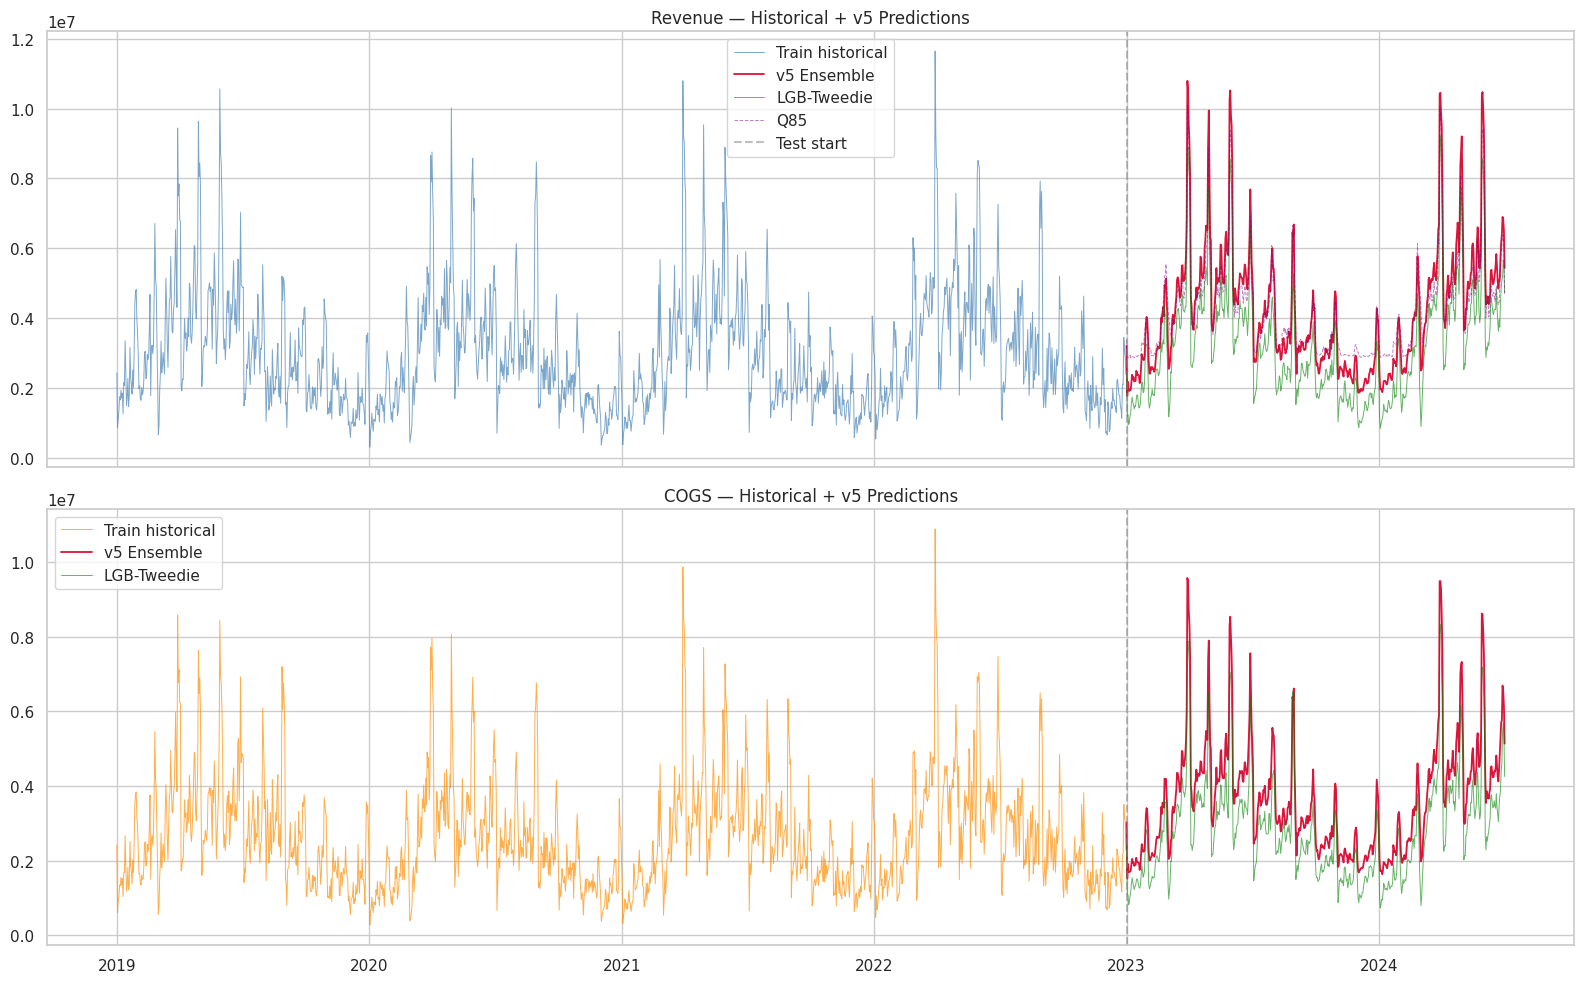

In [67]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
recent = sales[sales['Date'] >= '2019-01-01']

axes[0].plot(recent['Date'], recent['Revenue'], lw=0.7, label='Train historical', color='steelblue', alpha=0.7)
axes[0].plot(df.loc[test_mask, 'Date'], pred_rev_final, lw=1.3, label='v5 Ensemble', color='crimson')
axes[0].plot(df.loc[test_mask, 'Date'], pred_rev_lgb_test, lw=0.7, label='LGB-Tweedie', color='green', alpha=0.6)
axes[0].plot(df.loc[test_mask, 'Date'], pred_rev_q90_test, lw=0.7, ls='--', label='Q85', color='purple', alpha=0.5)
axes[0].axvline(test_start, ls='--', color='gray', alpha=0.5, label='Test start')
axes[0].set_title('Revenue — Historical + v5 Predictions'); axes[0].legend()

axes[1].plot(recent['Date'], recent['COGS'], lw=0.7, label='Train historical', color='darkorange', alpha=0.7)
axes[1].plot(df.loc[test_mask, 'Date'], pred_cog_final, lw=1.3, label='v5 Ensemble', color='crimson')
axes[1].plot(df.loc[test_mask, 'Date'], pred_cog_lgb_test, lw=0.7, label='LGB-Tweedie', color='green', alpha=0.6)
axes[1].axvline(test_start, ls='--', color='gray', alpha=0.5)
axes[1].set_title('COGS — Historical + v5 Predictions'); axes[1].legend()
plt.tight_layout(); plt.show()

1. Biểu đồ Scatter: Revenue vs COGS (Bắt bệnh ngoại lai)

Chuẩn: Các chấm xanh phải tạo thành một "đám mây" bám sát và chéo lên theo đường đứt nét màu đỏ.

Bệnh: Nếu má thấy có vài chấm xanh lơ lửng tít trên cao (rời xa đường màu đỏ), nghĩa là ở những ngày đó COGS bị nội suy sai lệch đắt một cách vô lý.

2. Biểu đồ Phân phối: Chuông Margin (Bắt bệnh ảo giác)

Chuẩn: Cột đồ thị phải tạo thành hình quả chuông (Normal Distribution), đỉnh chuông rơi vào khoảng 18% - 22%.

Bệnh: Nếu má thấy tự nhiên có một cái cột cao vút đứng lẻ loi ở mốc 10% (hoặc 1%), chứng tỏ "cái phanh chặn đáy" của chúng ta đang phải hoạt động quá sức để cứu các lỗi do mô hình dự báo sai.

3. Biểu đồ Doanh thu vs Margin (Bắt bệnh bão hòa)

Chuẩn: Dù doanh thu (trục X) có tiến dần lên mốc 8 triệu, 10 triệu hay 12 triệu, thì các chấm (Margin) vẫn dao động trong dải 15-25%.

Bệnh: Nếu doanh thu cứ hễ tăng cao là các chấm lại chúi đầu đi xuống chạm mức 10%, nghĩa là mô hình của má cứ gặp Spikes là bắt đầu đoán mò COGS quá tay.


Margin thwo tháng
  Month    Margin
2023-01 15.749004
2023-02 15.921595
2023-03 14.869772
2023-04 13.626243
2023-05 18.234965
2023-06 14.973510
2023-07  7.914270
2023-08  1.041258
2023-09  8.473835
2023-10 16.137125
2023-11 12.708840
2023-12  6.249054
2024-01 14.936556
2024-02 17.588793
2024-03 13.856524
2024-04 12.877833
2024-05 17.524587
2024-06 14.299509
2024-07  5.507258
----------------------------------------
Avg test set: 13.12%
----------------------------------------


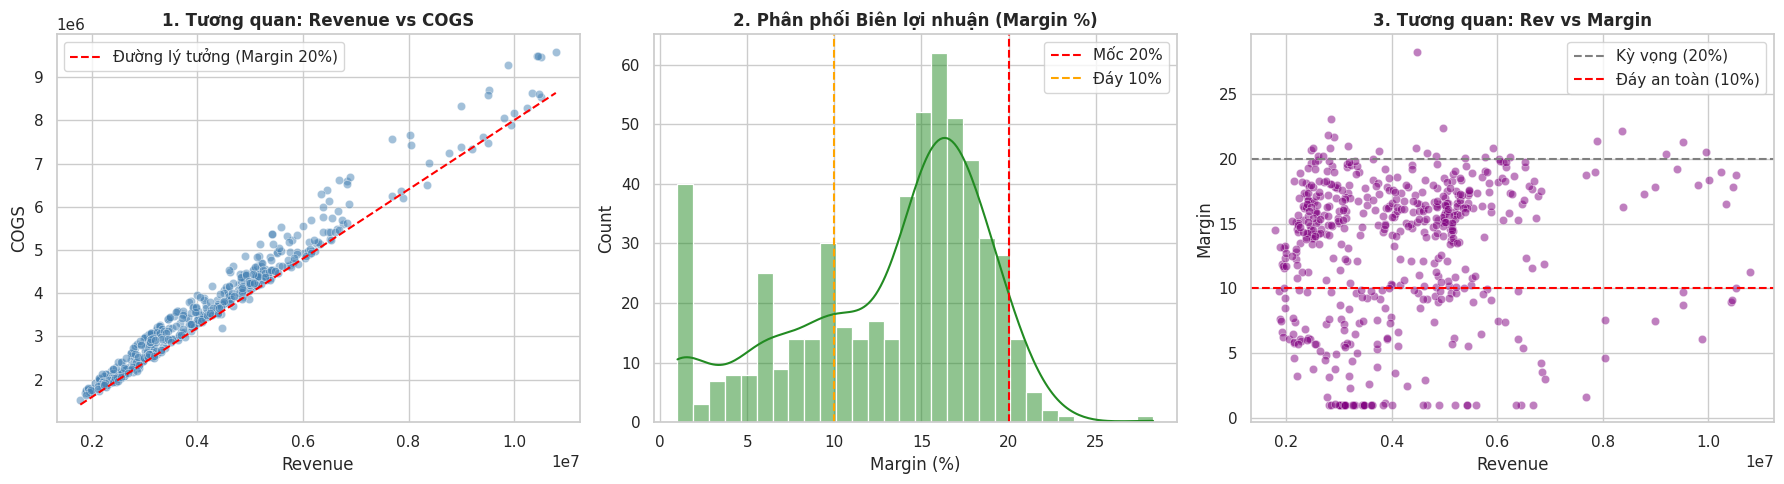

In [68]:
# Gom dữ liệu dự báo vào một DataFrame để dễ vẽ và tính toán
test_eval_df = pd.DataFrame({
    'Date': df.loc[test_mask, 'Date'].values,
    'Revenue': pred_rev_final,
    'COGS': pred_cog_final
})
test_eval_df['Margin'] = (1 - test_eval_df['COGS'] / test_eval_df['Revenue']) * 100
test_eval_df['Month'] = test_eval_df['Date'].dt.strftime('%Y-%m')

print("\nMargin thwo tháng")
monthly_margin = test_eval_df.groupby('Month')['Margin'].mean().reset_index()
print(monthly_margin.to_string(index=False))
print("-" * 40)
print(f"Avg test set: {test_eval_df['Margin'].mean():.2f}%")
print("-" * 40)

# corr charts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# Biểu đồ 1: Tương quan trực tiếp (Scatter) giữa Revenue và COGS
sns.scatterplot(data=test_eval_df, x='Revenue', y='COGS', alpha=0.5, color='steelblue', ax=axes[0])
# Vẽ đường Baseline tham chiếu (Margin 20% -> COGS = 80% Revenue)
x_line = np.linspace(test_eval_df['Revenue'].min(), test_eval_df['Revenue'].max(), 100)
y_line = x_line * 0.80
axes[0].plot(x_line, y_line, color='red', linestyle='--', label='Đường lý tưởng (Margin 20%)')
axes[0].set_title('1. Tương quan: Revenue vs COGS', fontweight='bold')
axes[0].legend()

# Biểu đồ 2: Phân phối (Histogram/KDE) của Margin
sns.histplot(test_eval_df['Margin'], bins=30, kde=True, color='forestgreen', ax=axes[1])
axes[1].axvline(20, color='red', linestyle='--', label='Mốc 20%')
axes[1].axvline(10, color='orange', linestyle='--', label='Đáy 10%')
axes[1].set_title('2. Phân phối Biên lợi nhuận (Margin %)', fontweight='bold')
axes[1].set_xlabel('Margin (%)')
axes[1].legend()

# Biểu đồ 3: Tương quan giữa Quy mô doanh thu và Margin
# Để check xem những ngày sale vọt lên > 8 triệu thì margin có bị sụp không
sns.scatterplot(data=test_eval_df, x='Revenue', y='Margin', alpha=0.5, color='purple', ax=axes[2])
axes[2].axhline(20, color='gray', linestyle='--', label='Kỳ vọng (20%)')
axes[2].axhline(10, color='red', linestyle='--', label='Đáy an toàn (10%)')
axes[2].set_title('3. Tương quan: Rev vs Margin', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

Biểu đồ 1: Xem cái đường màu cam (COGS) nó có chịu nằm ngoan ngoãn dưới đường màu đỏ (Revenue) trên toàn bộ dải thời gian hay không, hay vẫn bị "ngóc đầu" lên cắn Revenue ở cuối năm.

Biểu đồ 2 (Quan trọng nhất): Đường màu xanh lá (Margin) phải dao động quanh quẩn ở ranh giới 15% đến 25%. Tuyệt đối không có đoạn nào rớt một mạch xuống thành một đường nằm ngang ở mức 1% như file cũ.

Biểu đồ 3: Zoom kỹ vào khu vực hiện trường gây án (Tháng 08/2023). Khoảng cách giữa 2 đường đỏ và cam phải rộng rãi, mượt mà (khoảng 20%), chứng tỏ cái Trend Line tuyến tính đã hoạt động hoàn hảo.

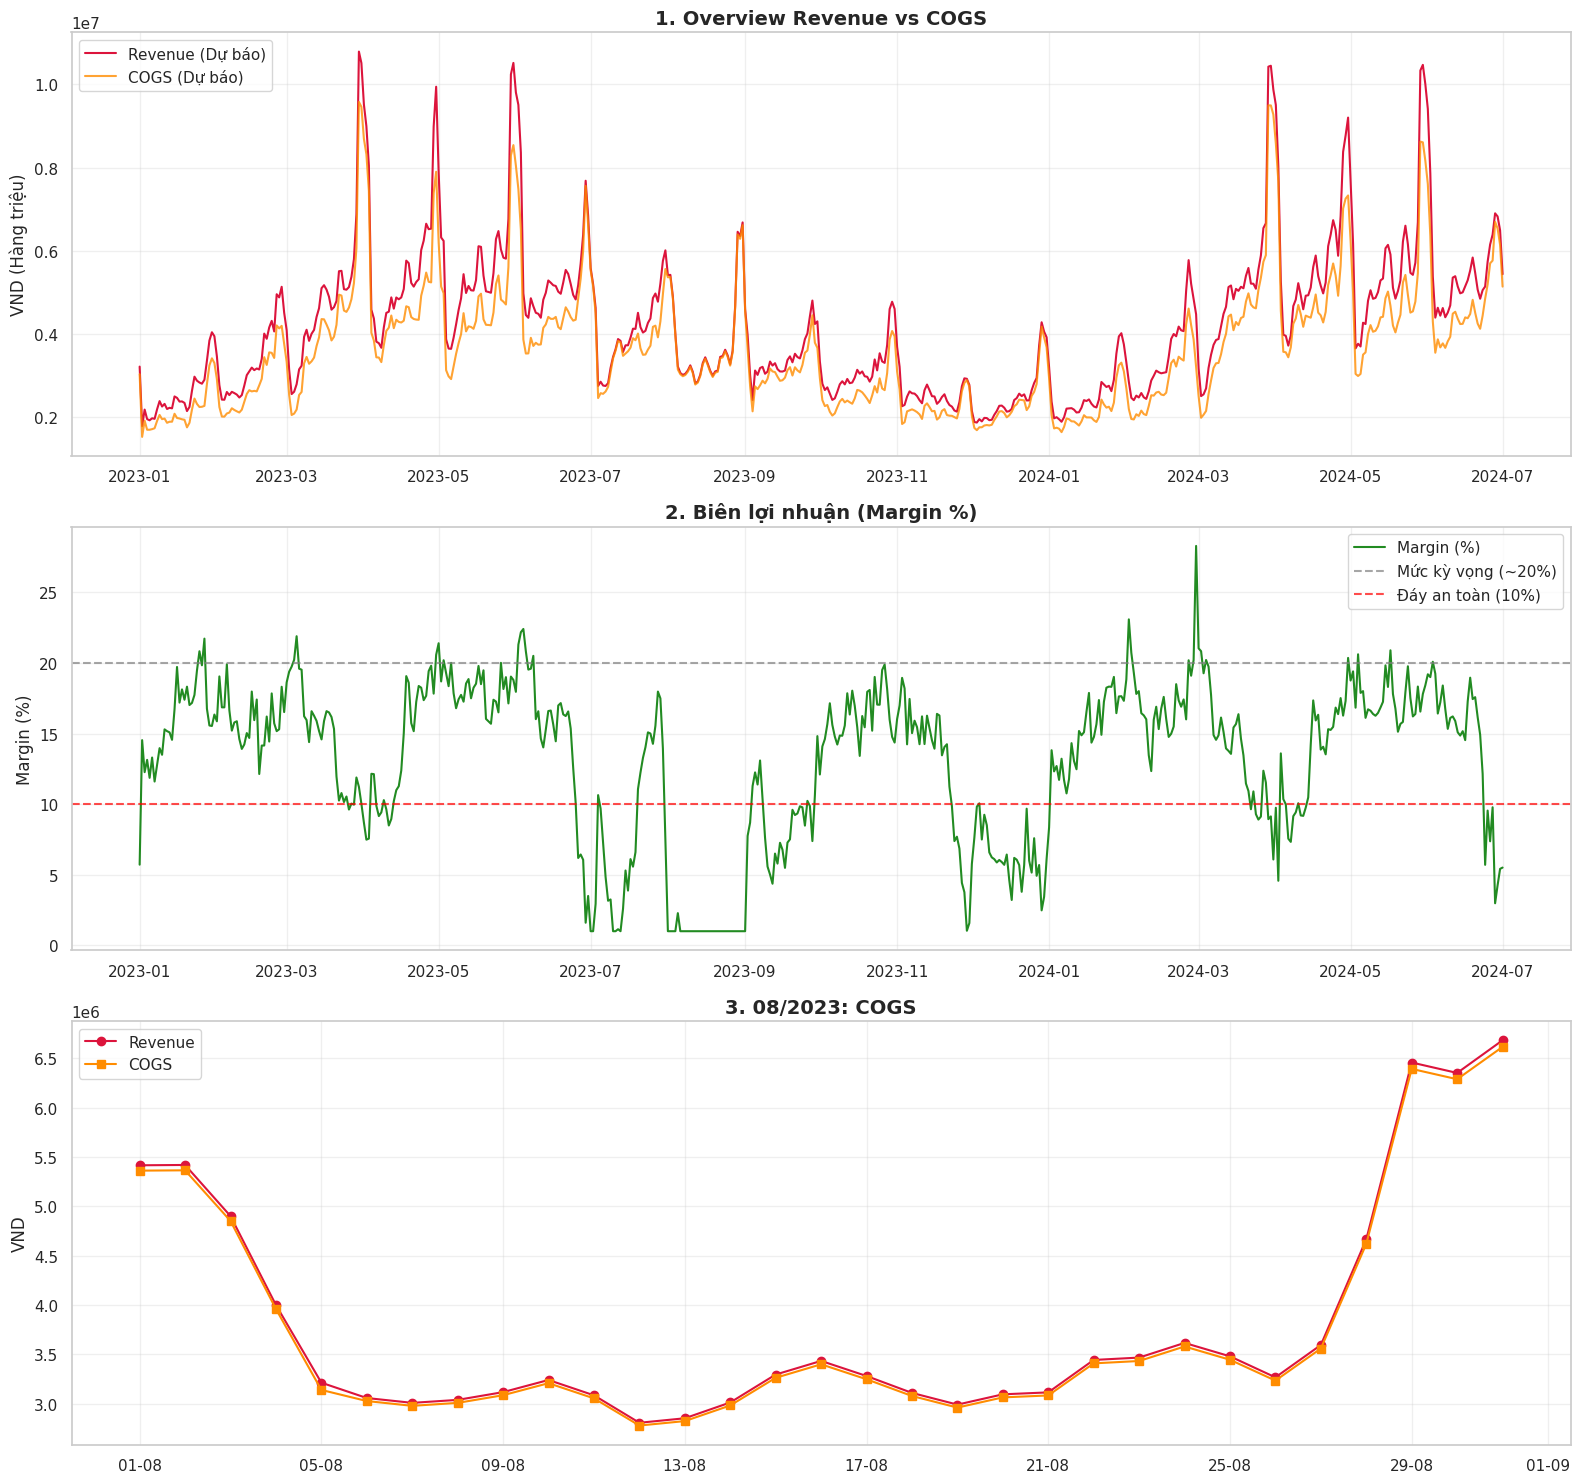

In [69]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Chuẩn bị dữ liệu
test_dates = df.loc[test_mask, 'Date'].reset_index(drop=True)
margin_final = (1 - pred_cog_final / pred_rev_final) * 100

# Tạo khung vẽ với 3 biểu đồ xếp dọc
fig, axes = plt.subplots(3, 1, figsize=(16, 15), sharex=False)

# Tổng quan Rev và cog
axes[0].plot(test_dates, pred_rev_final, label='Revenue (Dự báo)', color='crimson', lw=1.5)
axes[0].plot(test_dates, pred_cog_final, label='COGS (Dự báo)', color='darkorange', lw=1.5, alpha=0.8)
axes[0].set_title('1. Overview Revenue vs COGS', fontsize=14, fontweight='bold')
axes[0].set_ylabel('VND (Hàng triệu)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Soi margin
axes[1].plot(test_dates, margin_final, label='Margin (%)', color='forestgreen', lw=1.5)
axes[1].axhline(20, color='gray', linestyle='--', alpha=0.7, label='Mức kỳ vọng (~20%)')
axes[1].axhline(10, color='red', linestyle='--', alpha=0.7, label='Đáy an toàn (10%)')
axes[1].set_title('2. Biên lợi nhuận (Margin %)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Margin (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Lọc riêng data tháng 8
aug_mask = (test_dates >= '2023-08-01') & (test_dates <= '2023-08-31')

axes[2].plot(test_dates[aug_mask], pred_rev_final[aug_mask], label='Revenue', color='crimson', marker='o')
axes[2].plot(test_dates[aug_mask], pred_cog_final[aug_mask], label='COGS', color='darkorange', marker='s')
axes[2].set_title('3. 08/2023: COGS', fontsize=14, fontweight='bold')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%d-%m'))
axes[2].set_ylabel('VND')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

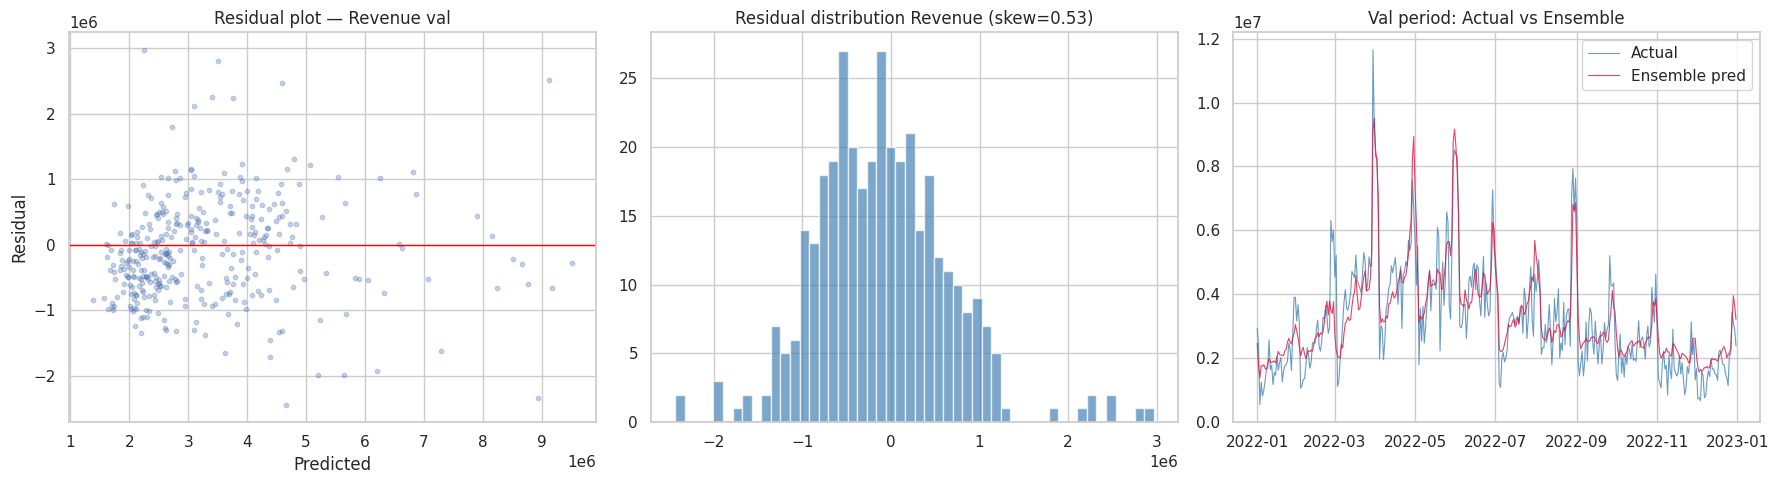

In [70]:
# Residual plot trên validation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

residuals_rev = y_rev_val - ens_rev_val
axes[0].scatter(ens_rev_val, residuals_rev, alpha=0.3, s=10)
axes[0].axhline(0, color='red', lw=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residual plot — Revenue val')

axes[1].hist(residuals_rev, bins=50, color='steelblue', alpha=0.7)
axes[1].set_title(f'Residual distribution Revenue (skew={pd.Series(residuals_rev).skew():.2f})')

# Val predictions vs actual
val_dates = df.loc[val_mask, 'Date'].values
axes[2].plot(val_dates, y_rev_val, lw=0.8, label='Actual', color='steelblue', alpha=0.8)
axes[2].plot(val_dates, ens_rev_val, lw=0.8, label='Ensemble pred', color='crimson', alpha=0.8)
axes[2].set_title('Val period: Actual vs Ensemble'); axes[2].legend()
plt.tight_layout(); plt.show()

In [71]:
# Tạo một bảng nháp chứa kết quả GỐC của thuật toán Cây (LGB + XGB + Prophet)
investigate_df = pd.DataFrame({
    'Date': df.loc[test_mask, 'Date'].reset_index(drop=True),
    'Base_Rev': base_rev_test,
    'Base_COGS': base_cog_test
})

# Tính Margin nguyên thủy (chưa ép Trend, chưa có np.minimum/maximum)
investigate_df['Base_Margin'] = (1 - investigate_df['Base_COGS'] / investigate_df['Base_Rev']) * 100
investigate_df['Month'] = investigate_df['Date'].dt.strftime('%Y-%m')

# In kết quả
print("\nBase margin")
base_monthly = investigate_df.groupby('Month')['Base_Margin'].mean().reset_index()
print(base_monthly[base_monthly['Month'].isin(['2023-07', '2023-08', '2023-09'])].to_string(index=False))

aug_margin = base_monthly.loc[base_monthly['Month'] == '2023-08', 'Base_Margin'].values[0]


Base margin
  Month  Base_Margin
2023-07     6.771239
2023-08   -10.908321
2023-09     7.041591


## 14. Feature Importance & SHAP

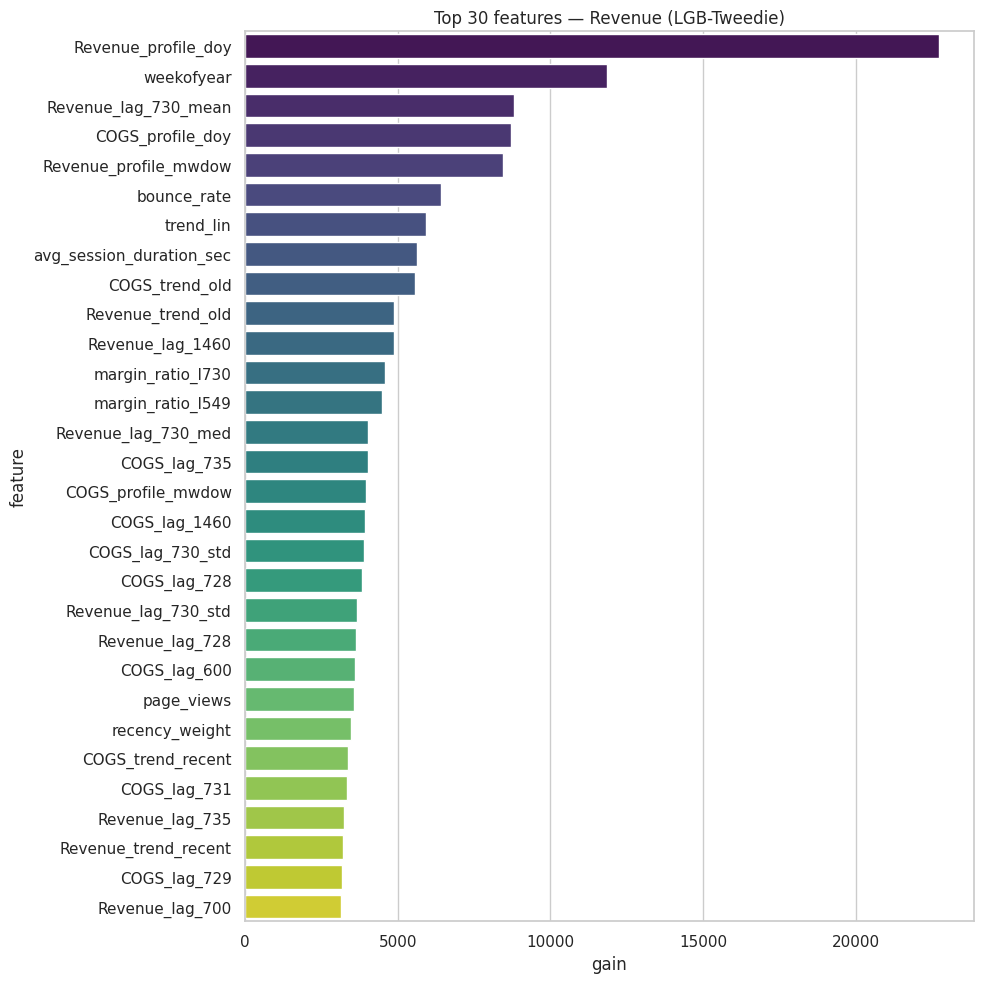

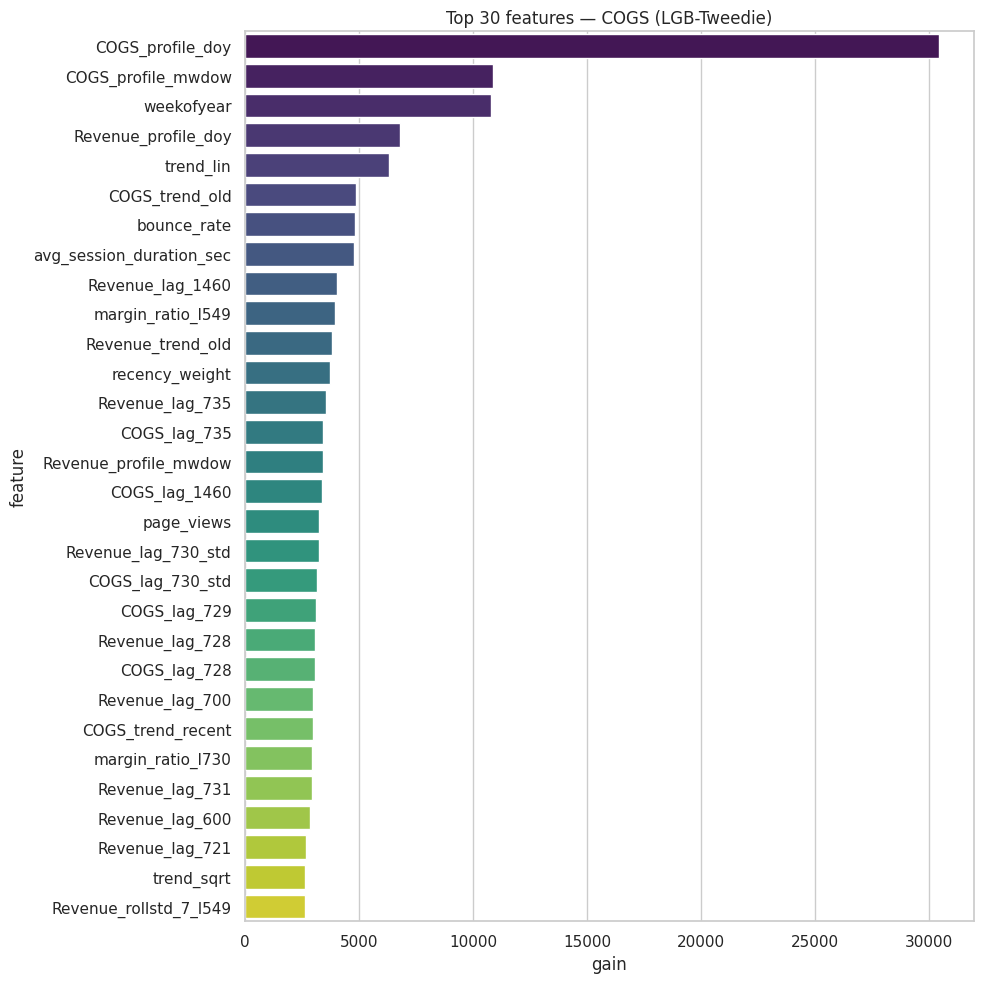

In [72]:
def plot_lgb_importance(model, title, top_n=30):
    imp = pd.DataFrame({
        'feature': FEATURES,
        'gain'   : model.feature_importance(importance_type='gain')
    }).sort_values('gain', ascending=False).head(top_n)

    plt.figure(figsize=(10, 10))
    sns.barplot(x='gain', y='feature', data=imp, palette='viridis')
    plt.title(title); plt.tight_layout(); plt.show()
    return imp

imp_rev = plot_lgb_importance(models_rev_lgb_full[0], 'Top 30 features — Revenue (LGB-Tweedie)')
imp_cog = plot_lgb_importance(models_cog_lgb_full[0], 'Top 30 features — COGS (LGB-Tweedie)')

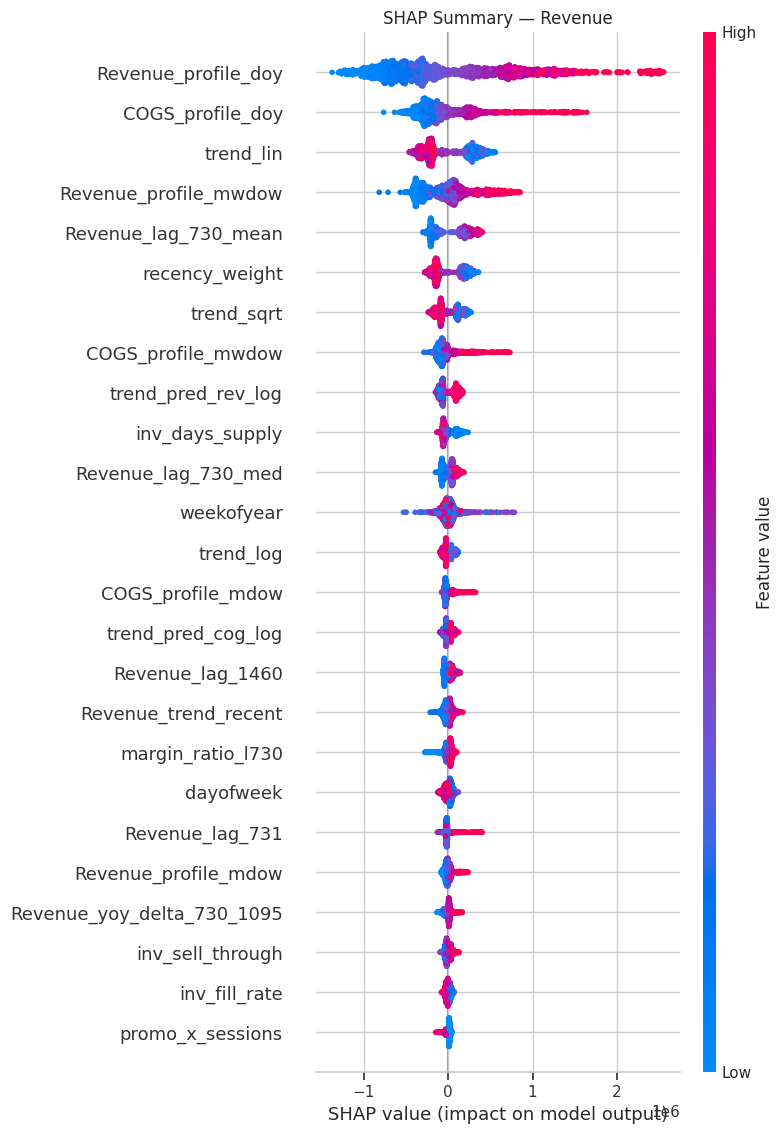

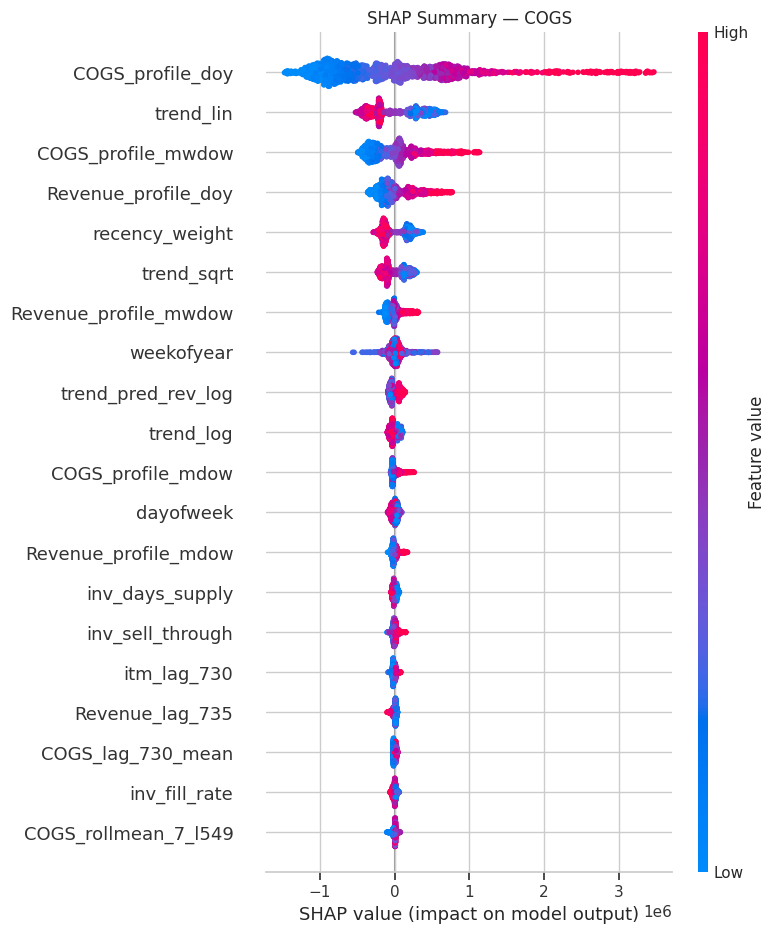

In [73]:
import matplotlib.pyplot as plt

# SHAP analysis
sample_idx   = df.loc[full_train_mask].sample(min(2000, full_train_mask.sum()), random_state=SEED).index
X_sample     = df.loc[sample_idx, FEATURES]

explainer_rev  = shap.TreeExplainer(models_rev_lgb_full[0])
shap_vals_rev  = explainer_rev.shap_values(X_sample)
shap.summary_plot(shap_vals_rev, X_sample, max_display=25, show=False)
plt.title('SHAP Summary — Revenue')
plt.tight_layout()
plt.show()

explainer_cog  = shap.TreeExplainer(models_cog_lgb_full[0])
shap_vals_cog  = explainer_cog.shap_values(X_sample)
shap.summary_plot(shap_vals_cog, X_sample, max_display=20, show=False)
plt.title('SHAP Summary — COGS')
plt.tight_layout()
plt.show()